## Q2.2 — Was the Nov 2017 Yishun Transaction Fairly Priced?

A flat was sold in **Nov 2017** with:

- Flat type: 4 ROOM
- Town: YISHUN
- Flat model: New Generation
- Storey range: 10 TO 12
- Floor area: 91 sqm
- Lease commence date: 1984
- Resale price: **550,800**

Approach:
1. Load transactions from **2016-01 to 2018-12** — a window centred on the transaction rather than a
   forecasting cutoff. This is an anomaly/fair-value check ("was this price consistent with comparable
   flats around that time?"), not a forecast, so using data from after Nov 2017 as well is legitimate
   and gives more relevant comparables than a strictly backward-looking window would (avoids stale
   2014-era price levels/market conditions). Join the same `geo_addresses_with_poi_2014` POI features
   used in `q1_2014_model.ipynb`.
2. Rescale historical prices to a **2017 Q4** basis — the transaction's own quarter — since we're no
   longer avoiding "future" information relative to the sale.
3. Train three models on the full window: Linear Regression, Random Forest, XGBoost.
4. Since the query flat has no known coordinates, first approximate its POI distances with the
   **Yishun-town average** (from training data) and predict.
5. If the average-distance prediction says 550,800 looks too expensive, re-run using the **Yishun-town
   min** distances (best-case location within the town) as a check on whether the best location could
   rationalize the price.
6. **Confidence**: build an empirical prediction interval from the model's residuals on a held-out
   validation slice, and see where 550,800 falls relative to that interval.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

curr_dir = Path.cwd()
DATA_DIR = curr_dir.parent.parent / "data"
SRC_DIR = curr_dir.parent
sys.path.append(str(SRC_DIR))

from utils import readjust_price, get_storey_mid

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_predict, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from xgboost import XGBRegressor

## 1. Load data and filter to 2016-01 – 2018-12

In [3]:
master_df = pd.read_csv(DATA_DIR / "merged_resale_prices.csv", parse_dates=["month"])
rpi = pd.read_csv(DATA_DIR / "rpi-table.csv")
geo_addresses_with_poi_2014 = pd.read_csv(DATA_DIR / "geo_addresses_with_poi_2014.csv")

WINDOW_START, WINDOW_END = "2016-01-01", "2018-12-31"
df = master_df[(master_df["month"] >= WINDOW_START) & (master_df["month"] <= WINDOW_END)].copy().reset_index(drop=True)
df["quarter"] = df["month"].dt.to_period("Q")

print(f"Rows {WINDOW_START} to {WINDOW_END}: {len(df):,}")
print(f"Date range: {df['month'].min().date()} to {df['month'].max().date()}")
df.head()

Rows 2016-01-01 to 2018-12-31: 61,443
Date range: 2016-01-01 to 2018-12-01


,month,town,flat_type,block,street_name,address,storey_range,floor_area_sqm,flat_model,lease_commence_date,flat_age_years,remaining_lease_years,resale_price,source_file,quarter
0,2016-01-01,ANG MO KIO,3 ROOM,223,ANG MO KIO AVE 1,223 ANG MO KIO AVE 1,07 TO 09,67.0,New Generation,1978,38,61,315000.0,Resale Flat Prices (Based on Registration Date...,2016Q1
1,2016-01-01,ANG MO KIO,4 ROOM,303,ANG MO KIO AVE 1,303 ANG MO KIO AVE 1,10 TO 12,97.0,New Generation,1977,39,60,465000.0,Resale Flat Prices (Based on Registration Date...,2016Q1
2,2016-01-01,ANG MO KIO,4 ROOM,304,ANG MO KIO AVE 1,304 ANG MO KIO AVE 1,07 TO 09,97.0,New Generation,1977,39,60,490000.0,Resale Flat Prices (Based on Registration Date...,2016Q1
3,2016-01-01,ANG MO KIO,3 ROOM,308A,ANG MO KIO AVE 1,308A ANG MO KIO AVE 1,16 TO 18,70.0,Model A,2012,4,95,459000.0,Resale Flat Prices (Based on Registration Date...,2016Q1
4,2016-01-01,ANG MO KIO,3 ROOM,308A,ANG MO KIO AVE 1,308A ANG MO KIO AVE 1,25 TO 27,70.0,Model A,2012,4,95,476000.0,Resale Flat Prices (Based on Registration Date...,2016Q1


In [4]:
df = df.merge(
    geo_addresses_with_poi_2014[["address", "dist_to_MRT", "dist_to_Mall", "dist_to_school", "dist_to_pop_school"]],
    how="left",
    on="address",
)
print("Null POI rows:", df[["dist_to_MRT", "dist_to_Mall", "dist_to_school", "dist_to_pop_school"]].isnull().any(axis=1).sum())
df.dropna(subset=["dist_to_MRT", "dist_to_Mall", "dist_to_school", "dist_to_pop_school"], inplace=True)
df.reset_index(drop=True, inplace=True)

Null POI rows: 0


## 2. Rescale prices to 2017 Q4 basis

Nov 2017 falls in **2017 Q4**. Since this is a fair-value check centred on the transaction (not a
forecast), we rebase every transaction's price directly to the transaction's own quarter — 2017 Q4 —
rather than holding back to an earlier "safe" quarter. This removes market-wide RPI trend across the
2016-2018 window so the model compares like-for-like price levels, and puts the actual price on the
exact same basis with no rescaling needed for it at all.

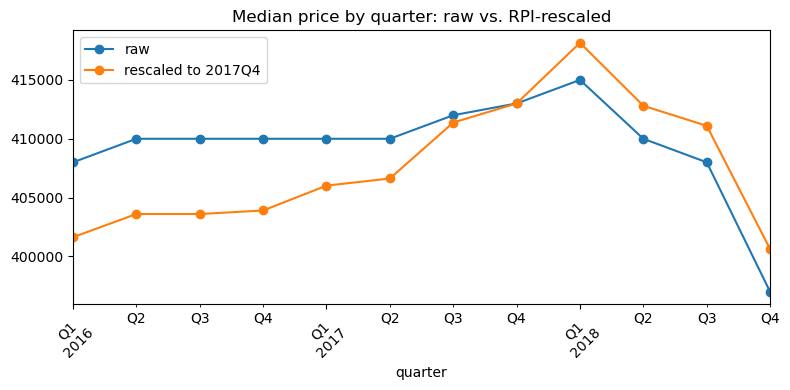

In [5]:
BASIS_YEAR, BASIS_QUARTER = 2017, 4
rescale_col = f"Rescale_price_{BASIS_YEAR}_Q{BASIS_QUARTER}"

df = readjust_price(df, rpi, target_year=BASIS_YEAR, target_quarter=BASIS_QUARTER)

fig, ax = plt.subplots(figsize=(8, 4))
df.groupby("quarter")["resale_price"].median().plot(ax=ax, marker="o", label="raw")
df.groupby("quarter")[rescale_col].median().plot(ax=ax, marker="o", label=f"rescaled to {BASIS_YEAR}Q{BASIS_QUARTER}")
ax.set_title("Median price by quarter: raw vs. RPI-rescaled")
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

## 3. Feature engineering + reusable pipeline

Same feature set and `build_pipeline` pattern as `q1_2014_model.ipynb`: `town`, `flat_type`,
`flat_model` one-hot encoded; `flat_age_years`, `mid_storey`, `floor_area_sqm`, and the four POI
distances as numeric features.

In [6]:
df["mid_storey"] = df["storey_range"].apply(get_storey_mid)

CATEGORICAL_FEATURES = ["town", "flat_type", "flat_model"]
NUMERIC_FEATURES = ["flat_age_years", "mid_storey", "floor_area_sqm", "dist_to_MRT", "dist_to_Mall", "dist_to_school", "dist_to_pop_school"]
FEATURE_COLS = CATEGORICAL_FEATURES + NUMERIC_FEATURES
TARGET_COL = rescale_col


def build_pipeline(model, scale_numeric: bool) -> Pipeline:
    numeric_steps = [("scaler", StandardScaler())] if scale_numeric else [("passthrough", "passthrough")]

    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
            ("num", Pipeline(numeric_steps) if scale_numeric else "passthrough", NUMERIC_FEATURES),
        ]
    )

    return Pipeline(steps=[("preprocess", preprocessor), ("model", model)])


def evaluate(y_true, y_pred) -> dict:
    return {
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "MAE": mean_absolute_error(y_true, y_pred),
        "MAPE": mean_absolute_percentage_error(y_true, y_pred),
    }

## 4. Train/validation split (for model selection only)

We need a held-out slice purely to **pick the best model type** honestly — this split is not reused
later for the confidence interval (see section 9, which uses k-fold CV across the full dataset
instead, so no data is wasted on the final estimate). A random 80/20 split (not a time split) is fine
here since the goal is a single point-in-time price check, not forecasting drift over future quarters.

In [7]:
RANDOM_STATE = 42

X = df[FEATURE_COLS]
y = df[TARGET_COL]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

print(f"Train rows: {len(X_train):,}")
print(f"Validation rows: {len(X_val):,}")

Train rows: 49,154
Validation rows: 12,289


## 5. Train and compare three models

Linear Regression, Random Forest, XGBoost — through the same `build_pipeline` factory as the 2014
notebook.

In [8]:
model_specs = {
    "LinearRegression": (LinearRegression(), True),
    "RandomForest": (RandomForestRegressor(n_estimators=200, max_depth=None, random_state=RANDOM_STATE, n_jobs=-1), False),
    "XGBoost": (XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.1, random_state=RANDOM_STATE, n_jobs=-1), False),
}

fitted_models = {}
val_residuals = {}
results = []

for name, (model, scale_numeric) in model_specs.items():
    pipe = build_pipeline(model, scale_numeric)
    pipe.fit(X_train, y_train)

    y_pred_val = pipe.predict(X_val)
    metrics = evaluate(y_val, y_pred_val)
    metrics["model"] = name
    results.append(metrics)

    fitted_models[name] = pipe
    val_residuals[name] = y_val.values - y_pred_val

    print(f"{name:16s}  RMSE={metrics['RMSE']:>10,.0f}  MAE={metrics['MAE']:>10,.0f} MAPE={metrics['MAPE']:>7.2%}")

results_df = pd.DataFrame(results).set_index("model")[["RMSE", "MAE", "MAPE"]].sort_values("RMSE")
results_df

LinearRegression  RMSE=    50,211  MAE=    38,040 MAPE=  9.20%
RandomForest      RMSE=    27,253  MAE=    19,007 MAPE=  4.40%
XGBoost           RMSE=    27,963  MAE=    20,265 MAPE=  4.70%


,RMSE,MAE,MAPE
model,,,
RandomForest,27252.857535,19006.512279,0.044010
XGBoost,27963.385704,20264.542258,0.047012
LinearRegression,50210.824753,38039.977552,0.092017


Best model by MAPE: RandomForest


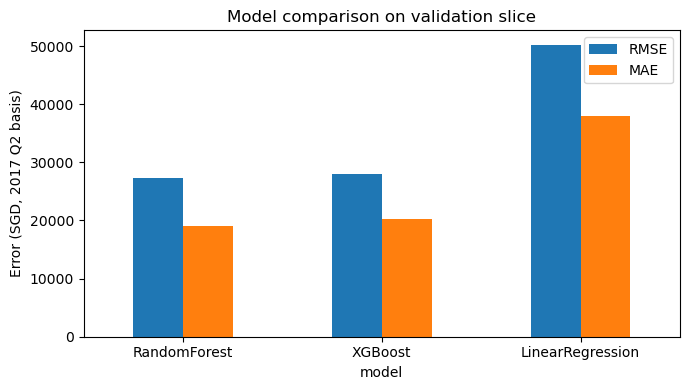

In [39]:
best_model_name = results_df["MAPE"].idxmin()
best_model = fitted_models[best_model_name]
best_residuals = val_residuals[best_model_name]
print(f"Best model by MAPE: {best_model_name}")

results_df[["RMSE", "MAE"]].plot(kind="bar", figsize=(7, 4), title="Model comparison on validation slice")
plt.ylabel("Error (SGD, 2017 Q2 basis)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

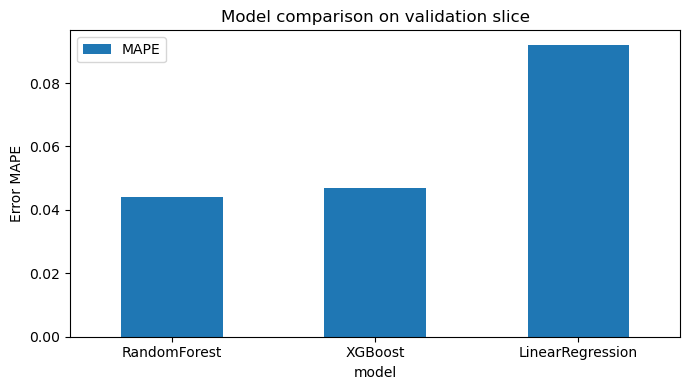

In [40]:
results_df[["MAPE"]].plot(kind="bar", figsize=(7, 4), title="Model comparison on validation slice")
plt.ylabel("Error MAPE")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Refit best model on all available data (2016-01 to 2018-12)

Once the best model is selected on the validation slice, refit it on the **full** window so the final
prediction for the query flat uses all available information, not just 80% of it. Residuals for the
confidence interval still come from the held-out validation predictions above (section 5), since those
are the only genuinely out-of-sample errors we have.

In [10]:
best_model_ctor, best_scale_numeric = model_specs[best_model_name]
final_model = type(best_model_ctor)(**best_model_ctor.get_params())
final_pipe = build_pipeline(final_model, best_scale_numeric)
final_pipe.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['town','flat_type','flat_model',...,'dist_to_Mall','dist_to_school', 'dist_to_pop_school']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This

## 7. Build the query flat and predict

The query flat has no geocoded address, so its POI distances are unknown. We first approximate them
with the **Yishun-town average** distance from training data (a "typical Yishun flat" assumption).

In [44]:
ACTUAL_PRICE = 550_800
TRANSACTION_MONTH = pd.Timestamp("2017-11-01")
LEASE_COMMENCE = 1984

yishun_df = df[df["town"] == "YISHUN"]
poi_cols = ["dist_to_MRT", "dist_to_Mall", "dist_to_school", "dist_to_pop_school"]
yishun_poi_avg = yishun_df[poi_cols].mean()
yishun_poi_min = yishun_df[poi_cols].min()

print("Yishun average POI distances:")
print(yishun_poi_avg)
print("\nYishun min POI distances:")
print(yishun_poi_min)


def build_query_row(poi_distances: pd.Series) -> pd.DataFrame:
    flat_age_years = TRANSACTION_MONTH.year - LEASE_COMMENCE
    row = {
        "town": "YISHUN",
        "flat_type": "4 ROOM",
        "flat_model": "New Generation",
        "flat_age_years": flat_age_years,
        "mid_storey": get_storey_mid("10 TO 12"),
        "floor_area_sqm": 91,
        "dist_to_MRT": poi_distances["dist_to_MRT"],
        "dist_to_Mall": poi_distances["dist_to_Mall"],
        "dist_to_school": poi_distances["dist_to_school"],
        "dist_to_pop_school": poi_distances["dist_to_pop_school"],
    }
    return pd.DataFrame([row])[FEATURE_COLS]


query_avg = build_query_row(yishun_poi_avg)
query_avg

Yishun average POI distances:
dist_to_MRT            734.653770
dist_to_Mall           646.030348
dist_to_school         338.124519
dist_to_pop_school    6971.703715
dtype: float64

Yishun min POI distances:
dist_to_MRT             43.105449
dist_to_Mall            81.874504
dist_to_school          45.729925
dist_to_pop_school    5660.187593
dtype: float64


,town,flat_type,flat_model,flat_age_years,mid_storey,floor_area_sqm,dist_to_MRT,dist_to_Mall,dist_to_school,dist_to_pop_school
0,YISHUN,4 ROOM,New Generation,33,11.0,91,734.65377,646.030348,338.124519,6971.703715


In [17]:
# Actual price on the same 2017 Q4 basis (its own quarter) — this rescale is a no-op (ratio = 1) since
# the transaction already occurred in the basis quarter, but keeping the call makes the comparison
# logic identical regardless of which quarter BASIS_YEAR/BASIS_QUARTER point to.
actual_row = pd.DataFrame({"month": [TRANSACTION_MONTH], "resale_price": [ACTUAL_PRICE]})
actual_rescaled = readjust_price(actual_row, rpi, target_year=BASIS_YEAR, target_quarter=BASIS_QUARTER)[rescale_col].iloc[0]

pred_avg = final_pipe.predict(query_avg)[0]

print(f"Actual price (raw, Nov 2017):        {ACTUAL_PRICE:,.0f}")
print(f"Actual price (rebased to {BASIS_YEAR}Q{BASIS_QUARTER}):   {actual_rescaled:,.0f}")
print(f"Predicted price (Yishun avg POI):     {pred_avg:,.0f}")
print(f"Difference (actual - predicted):      {actual_rescaled - pred_avg:,.0f}")
print(f"Difference (%):                       {(actual_rescaled - pred_avg) / pred_avg:.2%}")

Actual price (raw, Nov 2017):        550,800
Actual price (rebased to 2017Q4):   550,800
Predicted price (Yishun avg POI):     351,020
Difference (actual - predicted):      199,780
Difference (%):                       56.91%


## 8. Sensitivity check: best-case location within Yishun

Since the average-location prediction says 550,800 looks too expensive, check whether the flat could be
in the **most convenient part of Yishun** (min distance to MRT/mall/school/popular school) — which
would justifiably increase the model's prediction, and could lower the gap from average distance earlier. 


In [ ]:
query_min = build_query_row(yishun_poi_min)
pred_min = final_pipe.predict(query_min)[0]

print("Actual price looks HIGH relative to the average-location prediction — checking worst-case location.")
print(f"Predicted price (Yishun min/best-case POI): {pred_min:,.0f}")
print(f"Actual vs. best-case prediction:             {actual_rescaled - pred_min:,.0f}  ({(actual_rescaled - pred_min) / pred_min:.2%})")

Actual price looks HIGH relative to the average-location prediction — checking worst-case location.
Predicted price (Yishun min/best-case POI): 410,783
Actual vs. best-case prediction:             140,017  (34.09%)


## 9. Confidence: empirical prediction interval from k-fold out-of-fold residuals

A point prediction alone doesn't say how confident we should be. Section 5's 80/20 validation
residuals aren't a good match for `final_pipe` here — that model was refit on 100% of the data, so
using residuals from a model trained on only 80% would both waste data and be internally
inconsistent (the residuals wouldn't describe the actual final model).

Instead we use **k-fold cross-validation** (`cross_val_predict`, 5 folds) to get an out-of-fold
prediction for *every* row in the full dataset: each row is predicted by a model that never saw it
during training, so the residuals stay honestly out-of-sample, but we no longer throw away 20% of the
data for the final estimate — `final_pipe` (trained on all rows) is used only for the point prediction,
while the k-fold residuals (spanning the whole dataset) are used only for the interval. This gives a
much larger, more stable residual sample than a single static holdout, at the cost of those residuals
coming from models trained on ~80% of data each (one fold held out at a time) rather than the exact
100%-trained `final_pipe` — a standard, accepted approximation since the performance gap between an
80%-trained and 100%-trained model is typically small.

- A (1 - alpha) prediction interval for a new point is `prediction + [q_low, q_high]`, where `q_low`,
  `q_high` are the alpha/2 and 1 - alpha/2 quantiles of the out-of-fold residual distribution.
- This is nonparametric (no normality assumption on residuals) and reflects the model's actual
  out-of-sample error spread, including any skew/heteroskedasticity — appropriate here since price
  residuals are typically right-skewed (a few large positive misses).
- We check where the actual (rebased) price of 550,800 falls relative to this interval, and additionally
  report the residual's percentile — a direct read of "how unusual is a miss this large".

In [19]:
from scipy import stats

N_FOLDS = 5
ALPHA = 0.05  # 95% interval

kfold_model = type(best_model_ctor)(**best_model_ctor.get_params())
kfold_pipe = build_pipeline(kfold_model, best_scale_numeric)

cv = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
y_oof_pred = cross_val_predict(kfold_pipe, X, y, cv=cv, n_jobs=-1)
oof_residuals = y.values - y_oof_pred

mape_oof = mean_absolute_percentage_error(y, y_oof_pred)
print(f"Out-of-fold MAPE (pooled across {N_FOLDS} folds): {mape_oof:.2%}")
print(f"Out-of-fold residuals computed across {N_FOLDS} folds, {len(oof_residuals):,} rows total.")

q_low, q_high = np.quantile(oof_residuals, [ALPHA / 2, 1 - ALPHA / 2])

Out-of-fold MAPE (pooled across 5 folds): 4.33%
Out-of-fold residuals computed across 5 folds, 61,443 rows total.


In [25]:

q_low, q_high = np.quantile(oof_residuals, [ALPHA / 2, 1 - ALPHA / 2])

interval_low = pred_min + q_low
interval_high = pred_min + q_high

print(f"{best_model_name} out-of-fold residual quantiles ({ALPHA/2:.1%}, {1-ALPHA/2:.1%}): [{q_low:,.0f}, {q_high:,.0f}]")
print(f"{int((1-ALPHA)*100)}% empirical prediction interval for this flat: [{interval_low:,.0f}, {interval_high:,.0f}]")
print(f"Actual price: {actual_rescaled:,.0f}")

if interval_low <= actual_rescaled <= interval_high:
    print("-> Actual price FALLS WITHIN the interval: consistent with a fairly priced transaction.")
else:
    direction = "ABOVE" if actual_rescaled > interval_high else "BELOW"
    print(f"-> Actual price falls {direction} the interval: potentially over-priced.")

this_residual = actual_rescaled - pred_min
percentile = stats.percentileofscore(oof_residuals, this_residual)
print(f"\nThis transaction's residual ({this_residual:,.0f}) sits at the {percentile:.1f}th percentile of out-of-fold residuals.")
print(f"i.e. only {100 - percentile:.1f}% of transactions had a residual this large or larger.")

RandomForest out-of-fold residual quantiles (2.5%, 97.5%): [-52,544, 54,641]
95% empirical prediction interval for this flat: [358,239, 465,425]
Actual price: 550,800
-> Actual price falls ABOVE the interval: potentially over-priced.

This transaction's residual (140,017) sits at the 99.9th percentile of out-of-fold residuals.
i.e. only 0.1% of transactions had a residual this large or larger.


Absolute error may not be that suitable, since it is highly dependent on the actual price. A percentage may make more sense

In [54]:
oof_pct_residuals = (y.values - y_oof_pred) / y_oof_pred

# 2. Find the quantiles of the percentages (e.g., -0.05 and +0.06)
q_low_pct, q_high_pct = np.quantile(oof_pct_residuals, [ALPHA / 2, 1 - ALPHA / 2])

# 3. Apply the percentage bounds to your new prediction
# If pred_min is $350,000 and q_low_pct is -0.05, the lower bound becomes $332,500
interval_low = pred_min * (1 + q_low_pct)
interval_high = pred_min * (1 + q_high_pct)

print(f"{best_model_name} out-of-fold percentage quantiles: [{q_low_pct:.2%}, {q_high_pct:.2%}]")
print(f"{int((1-ALPHA)*100)}% empirical prediction interval: [{interval_low:,.0f}, {interval_high:,.0f}]")

this_residual_percentage = (actual_rescaled - pred_min)/pred_min
percentile= stats.percentileofscore(oof_pct_residuals, this_residual_percentage)
print(f"\nThis transaction's residual ({this_residual_percentage:.2%}) sits at the {percentile:.2f}th percentile of out-of-fold residuals percentage.")
print(f"i.e. only {100 - percentile:.2f}% of transactions had a residual this large or larger.")

RandomForest out-of-fold percentage quantiles: [-11.39%, 11.91%]
95% empirical prediction interval: [363,995, 459,701]

This transaction's residual (34.09%) sits at the 99.97th percentile of out-of-fold residuals percentage.
i.e. only 0.03% of transactions had a residual this large or larger.


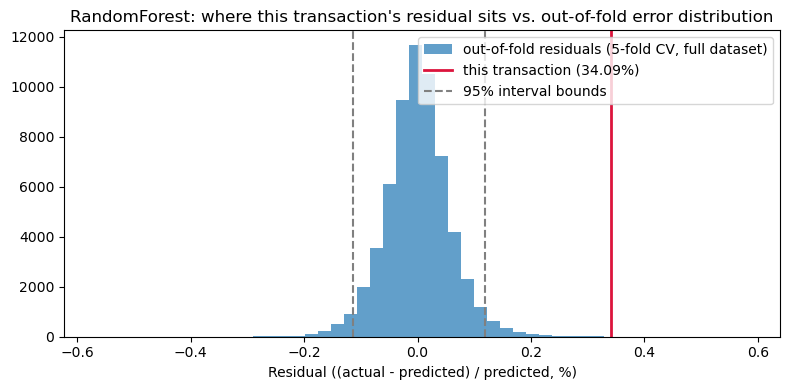

In [58]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(oof_pct_residuals, bins=50, alpha=0.7, label="out-of-fold residuals (5-fold CV, full dataset)")
ax.axvline(this_residual_percentage, color="crimson", linewidth=2, label=f"this transaction ({this_residual_percentage:.2%})")
ax.axvline(q_low_pct, color="gray", linestyle="--", label=f"{int((1-ALPHA)*100)}% interval bounds")
ax.axvline(q_high_pct, color="gray", linestyle="--")
ax.set_xlabel("Residual ((actual - predicted) / predicted, %)")
ax.set_title(f"{best_model_name}: where this transaction's residual sits vs. out-of-fold error distribution")
ax.legend()
plt.tight_layout()
plt.show()

## 10. Summary

- **Model comparison** (`results_df`): RMSE/MAE/MAPE for Linear Regression, Random Forest, and XGBoost
  on an 80/20 validation slice of 2016-01–2018-12 transactions, rebased to a 2017 Q4 basis (the
  transaction's own quarter) — used only to pick the best model type.
- **Best model** Random Forest: selected by lowest validation MAPE, then refit on the full window (`final_pipe`) for
  the final point estimate.
- **Point estimate**: predicted fair price for the query flat assuming Yishun-average POI distances,
  compared against the actual price (550,800), both on the 2017 Q4 basis.
- **Best-case location check**: re-run with Yishun-min POI distances because the average-location estimate
  suggested the actual price was too high, to see whether the best location within Yishun could
  rationalize it. Prediction still lower compared to value, 34.09% difference. 
- **Confidence**: an empirical prediction interval built from **5-fold cross-validated out-of-fold
  residuals** across the full dataset (quantile-based, no normality assumption) — chosen over the
  80/20 validation residuals so the interval doesn't waste data and stays consistent with `final_pipe`
  being trained on all rows. Reports both an interval and the actual transaction's residual
  percentile — together answering not just "was this over/underpriced" but "how confident are we."